In [1]:
import pandas as pd
df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

df_tx = df_tx.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

df_px = df_px.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df = pd.read_csv('./data/cytof.csv', index_col=0)

df_p = df[df['simulationConditionId'].str.split('__').str[1]=='EGF'].pivot_table(
    index='preequilibrationConditionId', columns='FEATURE_ID', values='measurement'
)

df_tx.index = [f't{m}' for m in df_tx.index]
df_px.index = [f'p{m}' for m in df_px.index]

df = pd.concat([df_p, df_tx.T, df_px.T], axis=1)

/Users/fabring/dmm_env_310/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


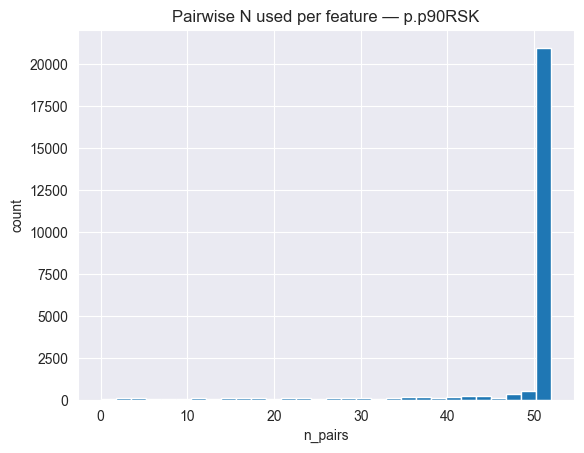

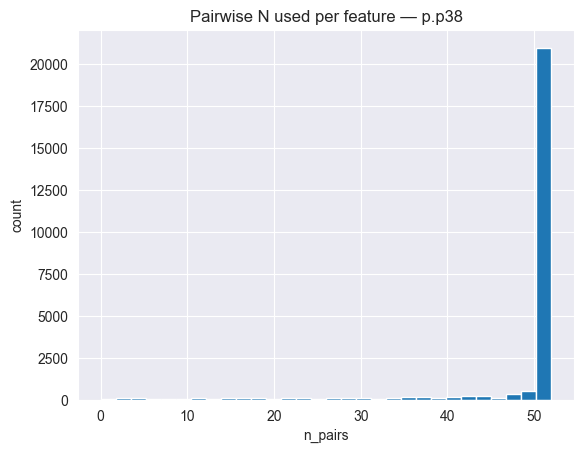

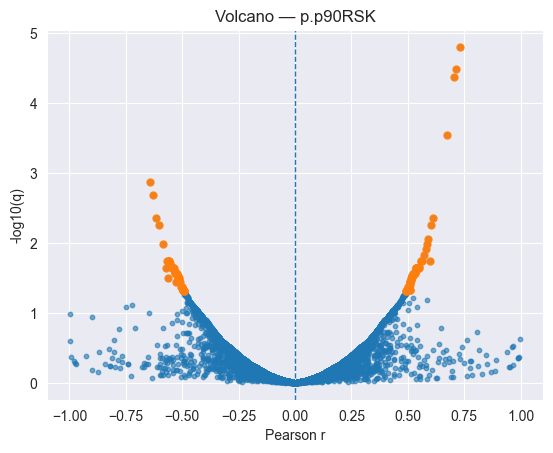

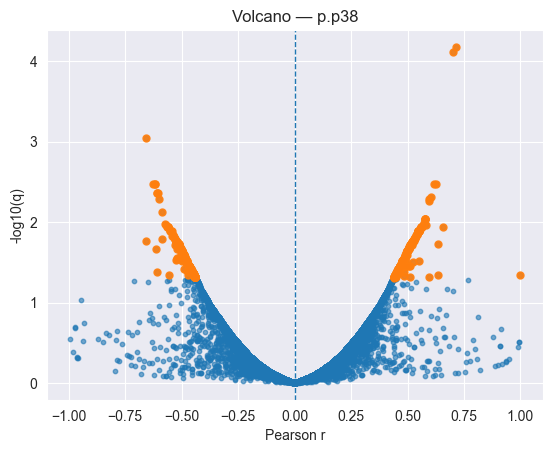

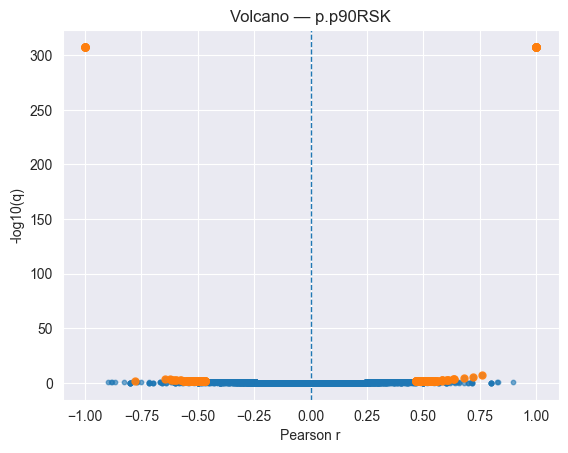

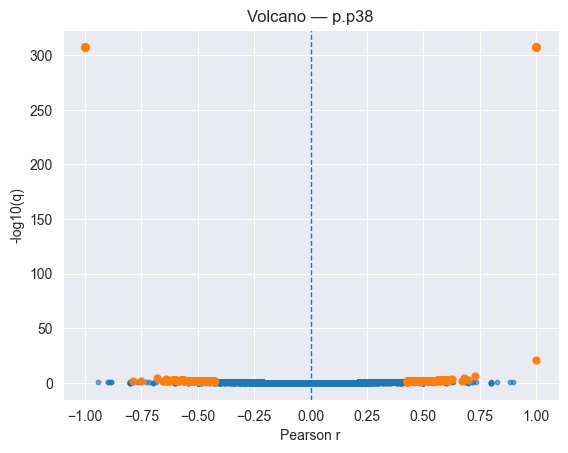

,marker,feature,n_pairs,pearson_r,pearson_p,pearson_ci_lo,pearson_ci_hi,spearman_rho,spearman_p,pearson_q,pearson_reject,spearman_q,spearman_reject,is_omics
22270,p.p90RSK,pRHOT2,52,-0.642628,2.803162e-07,-0.778925,-0.448357,-0.645010,2.450710e-07,0.001364,True,0.000238,True,True
11871,p.p90RSK,tRNF41,52,-0.631521,5.166648e-07,-0.771465,-0.433296,-0.605934,1.935887e-06,0.002095,True,0.001410,True,True
2200,p.p90RSK,tCCDC78,52,-0.614209,1.279068e-06,-0.759760,-0.410039,-0.621702,8.697965e-07,0.004380,True,0.000730,True,True
22018,p.p90RSK,pRAB12,52,0.611858,1.440643e-06,0.406900,0.758163,0.605566,1.971299e-06,0.004380,True,0.001410,True,True
14980,p.p90RSK,tTSPAN2,52,0.602749,2.263619e-06,0.394787,0.751959,0.543072,3.185250e-05,0.005506,True,0.012496,True,True
4640,p.p90RSK,tFAHD1,52,-0.604768,2.050310e-06,-0.753337,-0.397467,-0.616836,1.118608e-06,0.005506,True,0.000907,True,True
21027,p.p90RSK,pNSFL1C,52,0.591300,3.917416e-06,0.379665,0.744124,0.581661,6.117579e-06,0.008662,True,0.003720,True,True
7198,p.p90RSK,tKIAA1257,52,-0.584236,5.438515e-06,-0.739269,-0.370390,-0.595307,3.241020e-06,0.010323,True,0.002131,True,True
6273,p.p90RSK,tHLA.DMB,52,0.578606,7.025257e-06,0.363028,0.735387,0.610241,1.562590e-06,0.012206,True,0.001207,True,True
24141,p.p90RSK,pVCL,52,0.572228,9.335469e-06,0.354722,0.730978,0.600188,2.563850e-06,0.015138,True,0.001782,True,True


In [65]:
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.stats import pearsonr, spearmanr, rankdata, norm
from statsmodels.stats.multitest import multipletests

def nancorr_p(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 39:  # safeguard - only return a correlation if there are more than 75% of paired datapoints
        return np.nan, np.nan
    r, p = pearsonr(a[mask], b[mask])
    return r, p


# === Config flags ===
PER_MARKER_FDR = True             # <- set False to correct across all markers combined
INCLUDE_SPEARMAN = True           # <- set False to skip Spearman
CONFIDENCE = 0.95                      # <- for 95% CI

markers = [
    'p.p90RSK',
    # 'p.ERK',
    'p.p38'
]

# --- Helpers ---
def fisher_ci(r, n, confidence=0.95):
    """
    Fisher z CI for Pearson r. Returns (lo, hi).
    For n <= 3 or |r|==1, returns (np.nan, np.nan).
    doc: https://en.wikipedia.org/wiki/Fisher_transformation
    """
    if n is None or n <= 3 or not np.isfinite(r) or abs(r) >= 1:
        return np.nan, np.nan
    z = np.arctanh(r)  # Fisher z
    se = 1.0 / math.sqrt(n - 3)
    zcrit = norm.ppf(1 - (1-confidence)/2)
    lo = np.tanh(z - zcrit * se)
    hi = np.tanh(z + zcrit * se)
    return lo, hi

def correlate_marker(marker, df, include_spearman=True, confidence=0.95):
    """
    Compute Pearson (r, p, CI) and optionally Spearman (rho, p, CI) vs all features for one marker.
    No arbitrary overlap cutoff: requires minimum n>=3 to compute.
    Returns a tidy DataFrame.
    """
    if marker not in df.columns:
        raise KeyError(f"Marker {marker} not in columns.")
    target = df[marker].values
    cols = [c for c in df.columns if c != marker]
    out_rows = []

    for c in cols:
        x = target
        y = df[c].values
        mask = np.isfinite(x) & np.isfinite(y)
        n = int(mask.sum())

        # Pearson
        if n >= 3:
            r, p = pearsonr(x[mask], y[mask])
            r_lo, r_hi = fisher_ci(r, n, confidence)
        else:
            r = p = r_lo = r_hi = np.nan

        row = {
            'marker': marker,
            'feature': c,
            'n_pairs': n,
            'pearson_r': r,
            'pearson_p': p,
            'pearson_ci_lo': r_lo,
            'pearson_ci_hi': r_hi,
        }

        # Spearman (optional)
        if include_spearman:
            if n >= 3:
                rho, p_s = spearmanr(x[mask], y[mask])
            else:
                rho = p_s = np.nan
            row.update({
                'spearman_rho': rho,
                'spearman_p': p_s,
            })

        out_rows.append(row)

    return pd.DataFrame(out_rows)

# --- Run correlations for all markers ---
frames = []
for m in markers:
    frames.append(
        correlate_marker(
            m, df,
            include_spearman=INCLUDE_SPEARMAN,
            confidence=CONFIDENCE
        )
    )
res_df = pd.concat(frames, ignore_index=True)

# --- Multiple testing correction (per-marker by default) ---
def apply_fdr(df, per_marker=True, p_col='pearson_p', prefix='pearson', alpha=0.05):
    out = df.copy()
    out[f'{prefix}_q'] = np.nan
    out[f'{prefix}_reject'] = False

    if per_marker:
        for m in out['marker'].unique():
            ix = out['marker'].eq(m) & out[p_col].notna() & np.isfinite(out[p_col])
            if ix.any():
                rej, q, _, _ = multipletests(out.loc[ix, p_col].values, method='fdr_bh', alpha=alpha)
                out.loc[ix, f'{prefix}_q'] = q
                out.loc[ix, f'{prefix}_reject'] = rej.astype(bool)
    else:
        ix = out[p_col].notna() & np.isfinite(out[p_col])
        if ix.any():
            rej, q, _, _ = multipletests(out.loc[ix, p_col].values, method='fdr_bh', alpha=alpha)
            out.loc[ix, f'{prefix}_q'] = q
            out.loc[ix, f'{prefix}_reject'] = rej.astype(bool)

    return out

res_df = apply_fdr(res_df, per_marker=PER_MARKER_FDR, p_col='pearson_p', prefix='pearson')

if INCLUDE_SPEARMAN:
    res_df = apply_fdr(res_df, per_marker=PER_MARKER_FDR, p_col='spearman_p', prefix='spearman')

# --- Example filters you might care about (keep or remove) ---
# Omics vs CyTOF split (optional)
omics_cols = set(df_tx.T.columns).union(df_px.T.columns)
res_df['is_omics'] = res_df['feature'].isin(omics_cols)

# === QC PLOTS ===
# 1) For each marker: histogram of n_pairs used
for m in markers:
    dd = res_df[res_df.marker == m]
    plt.figure()
    plt.hist(dd['n_pairs'].dropna(), bins=30)
    plt.title(f'Pairwise N used per feature — {m}')
    plt.xlabel('n_pairs')
    plt.ylabel('count')
    plt.show()

# 2) Volcano plots (Pearson): r vs -log10(q)
def volcano(df, marker, effect_col='pearson_r', q_col='pearson_q', reject_col='pearson_reject'):
    d = df[df.marker == marker].copy()
    d = d[np.isfinite(d[effect_col]) & np.isfinite(d[q_col])]
    if d.empty:
        return
    d['neglog10q'] = -np.log10(d[q_col].clip(lower=np.finfo(float).tiny))
    plt.figure()
    # all points
    plt.scatter(d[effect_col], d['neglog10q'], s=10, alpha=0.6)
    # overlay rejected (larger markers)
    if reject_col in d.columns:
        d_sig = d[d[reject_col]]
        if not d_sig.empty:
            plt.scatter(d_sig[effect_col], d_sig['neglog10q'], s=25, alpha=0.9)
    plt.axvline(0, linestyle='--', linewidth=1)
    plt.title(f'Volcano — {marker}')
    plt.xlabel('Pearson r')
    plt.ylabel('-log10(q)')
    plt.show()

for m in markers:
    volcano(res_df, m, effect_col='pearson_r', q_col='pearson_q', reject_col='pearson_reject')

# (Optional) Volcano for Spearman as well
if INCLUDE_SPEARMAN:
    for m in markers:
        volcano(res_df, m, effect_col='spearman_rho', q_col='spearman_q', reject_col='spearman_reject')

# --- Result preview: significant omics for p.p90RSK by Pearson FDR ---
res_df.query("marker == 'p.p90RSK' and is_omics and pearson_reject").sort_values('pearson_q').head(20)

In [66]:
res_df.query("marker == 'p.p90RSK' and is_omics and pearson_reject and spearman_reject").sort_values('pearson_q')

,marker,feature,n_pairs,pearson_r,pearson_p,pearson_ci_lo,pearson_ci_hi,spearman_rho,spearman_p,pearson_q,pearson_reject,spearman_q,spearman_reject,is_omics
22270,p.p90RSK,pRHOT2,52,-0.642628,2.803162e-07,-0.778925,-0.448357,-0.645010,2.450710e-07,0.001364,True,0.000238,True,True
11871,p.p90RSK,tRNF41,52,-0.631521,5.166648e-07,-0.771465,-0.433296,-0.605934,1.935887e-06,0.002095,True,0.001410,True,True
2200,p.p90RSK,tCCDC78,52,-0.614209,1.279068e-06,-0.759760,-0.410039,-0.621702,8.697965e-07,0.004380,True,0.000730,True,True
22018,p.p90RSK,pRAB12,52,0.611858,1.440643e-06,0.406900,0.758163,0.605566,1.971299e-06,0.004380,True,0.001410,True,True
14980,p.p90RSK,tTSPAN2,52,0.602749,2.263619e-06,0.394787,0.751959,0.543072,3.185250e-05,0.005506,True,0.012496,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11556,p.p90RSK,tRCAN1,52,0.493873,1.986332e-04,0.255395,0.675704,0.488367,2.397155e-04,0.048417,True,0.037729,True,True
10771,p.p90RSK,tPPP1R10,52,-0.493813,1.990483e-04,-0.675660,-0.255320,-0.538345,3.845560e-05,0.048417,True,0.014616,True,True
8656,p.p90RSK,tMRPS33,52,-0.493953,1.980884e-04,-0.675761,-0.255493,-0.470458,4.324316e-04,0.048417,True,0.046498,True,True
3891,p.p90RSK,tDNAJC14,52,-0.492685,2.069175e-04,-0.674849,-0.253925,-0.499189,1.651633e-04,0.049344,True,0.032655,True,True


In [67]:
res_df.query("marker == 'p.p38' and is_omics and pearson_reject and spearman_reject").sort_values('pearson_q')

,marker,feature,n_pairs,pearson_r,pearson_p,pearson_ci_lo,pearson_ci_hi,spearman_rho,spearman_p,pearson_q,pearson_reject,spearman_q,spearman_reject,is_omics
31673,p.p38,tKIAA1257,52,-0.658800,1.099746e-07,-0.789720,-0.470488,-0.679302,3.087212e-08,0.000892,True,0.000040,True,True
46745,p.p38,pRHOT2,52,-0.625449,7.145311e-07,-0.767371,-0.425109,-0.640485,3.160158e-07,0.003380,True,0.000384,True,True
32222,p.p38,tLRFN2,52,-0.619162,9.924061e-07,-0.763118,-0.416665,-0.620179,9.414838e-07,0.003380,True,0.001041,True,True
41638,p.p38,pATIC,52,-0.616958,1.111648e-06,-0.761625,-0.413714,-0.607103,1.827069e-06,0.003380,True,0.001597,True,True
26675,p.p38,tCCDC78,52,-0.607062,1.830810e-06,-0.754900,-0.400514,-0.605481,1.979614e-06,0.004351,True,0.001612,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33850,p.p38,tNPC1,52,0.440844,1.071747e-03,0.190912,0.637097,0.461795,5.687470e-04,0.048191,True,0.031441,True,True
25139,p.p38,tANKRD30A,52,-0.440766,1.074188e-03,-0.637040,-0.190819,-0.444081,9.743499e-04,0.048191,True,0.040306,True,True
25042,p.p38,tAMBP,52,-0.441003,1.066749e-03,-0.637215,-0.191102,-0.459167,6.171640e-04,0.048191,True,0.032725,True,True
27659,p.p38,tCREB3L4,52,-0.440527,1.081738e-03,-0.636864,-0.190533,-0.446342,9.111004e-04,0.048191,True,0.038580,True,True


In [37]:
res_df[res_df.feature.isin(["pRTN3", "tRTN3"])]

,marker,feature,n_pairs,pearson_r,pearson_p,pearson_ci_lo,pearson_ci_hi,spearman_rho,spearman_p,pearson_q,pearson_reject,spearman_q,spearman_reject,is_omics
12099,p.p90RSK,tRTN3,52,-0.087723,0.536312,-0.352192,0.189719,-0.020448,0.885594,0.837047,False,0.962519,False,True
22497,p.p90RSK,pRTN3,52,-0.181321,0.198292,-0.432805,0.096347,-0.109707,0.438801,0.585670,False,0.761189,False,True
36574,p.p38,tRTN3,52,0.051213,0.718426,-0.224829,0.319646,0.033724,0.812391,0.882620,False,0.922153,False,True
46972,p.p38,pRTN3,52,-0.008437,0.952664,-0.280691,0.265074,-0.039102,0.783148,0.980893,False,0.909537,False,True


In [38]:
res_df[res_df.feature.isin(["pETV4", "tETV4"])]

,marker,feature,n_pairs,pearson_r,pearson_p,pearson_ci_lo,pearson_ci_hi,spearman_rho,spearman_p,pearson_q,pearson_reject,spearman_q,spearman_reject,is_omics
4546,p.p90RSK,tETV4,52,0.508103,0.00012,0.273066,0.685896,0.454932,0.000703,0.036786,True,0.059174,False,True
29021,p.p38,tETV4,52,0.244930,0.08011,-0.029974,0.485387,0.182707,0.194826,0.331225,False,0.495109,False,True


In [43]:
res_df[res_df.feature.isin(["pRNF41", "tRNF41"])]

,marker,feature,n_pairs,pearson_r,pearson_p,pearson_ci_lo,pearson_ci_hi,spearman_rho,spearman_p,pearson_q,pearson_reject,spearman_q,spearman_reject,is_omics
11871,p.p90RSK,tRNF41,52,-0.631521,5.166648e-07,-0.771465,-0.433296,-0.605934,0.000002,0.002095,True,0.001410,True,True
36346,p.p38,tRNF41,52,-0.521199,7.441780e-05,-0.695215,-0.289472,-0.505528,0.000132,0.017574,True,0.015969,True,True


Proteomics - p90RSK

In [68]:
import gseapy as gp

gl = [g[1:] for g in res_df.query("marker == 'p.p90RSK' and is_omics and pearson_reject and spearman_reject").feature.unique() if g.startswith('p')]
bg = [g[1:] for g in res_df.feature.unique() if g.startswith('p')]

# Enrichr-style analysis (GO, KEGG, Reactome, MSigDB etc.)
enr = gp.enrichr(
    gene_list=gl,
    background=bg,
    gene_sets=['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human'],
    organism='Human',
    cutoff=0.05
)

enr.results[enr.results["Adjusted P-value"] <= 0.05]

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,ATP Biosynthetic Process (GO:0006754),4.239851e-07,1.021804e-04,0,0,92.222874,1353.238565,ATP5F1B;ATP5PB;ATP5F1D;ATP5MG
1,GO_Biological_Process_2025,Proton Motive Force-Driven ATP Synthesis (GO:0...,2.316818e-06,1.861177e-04,0,0,28.992593,376.188047,ATP5F1B;NDUFB10;ATP5PB;ATP5F1D;ATP5MG
2,GO_Biological_Process_2025,Proton Motive Force-Driven Mitochondrial ATP S...,2.316818e-06,1.861177e-04,0,0,28.992593,376.188047,ATP5F1B;NDUFB10;ATP5PB;ATP5F1D;ATP5MG
3,GO_Biological_Process_2025,Oxidative Phosphorylation (GO:0006119),4.478042e-06,2.698021e-04,0,0,25.067308,308.737098,ATP5F1B;NDUFB10;ATP5PB;ATP5F1D;ATP5MG
4,GO_Biological_Process_2025,Mitochondrial Translation (GO:0032543),4.233332e-05,2.040466e-03,0,0,15.270588,153.773846,MRPL20;MRPL3;MRPL18;MRPL19;MRPL9
5,GO_Biological_Process_2025,Mitochondrial Gene Expression (GO:0140053),5.493205e-05,2.206437e-03,0,0,14.412963,141.382716,MRPL20;MRPL3;MRPL18;MRPL19;MRPL9
6,GO_Biological_Process_2025,Actin Filament Network Formation (GO:0051639),2.822974e-04,9.719097e-03,0,0,119.227273,974.390771,PLS3;PLS1
7,GO_Biological_Process_2025,Dicarboxylic Acid Metabolic Process (GO:0043648),6.025780e-04,1.815266e-02,0,0,20.994643,155.660443,FAHD1;OGDHL;GCLM
8,GO_Biological_Process_2025,Response to Copper Ion (GO:0046688),1.439657e-03,3.855080e-02,0,0,43.316804,283.437044,MT1X;ATP5F1D
241,GO_Cellular_Component_2025,Mitochondrial Inner Membrane (GO:0005743),7.010355e-08,5.468077e-06,0,0,11.219525,184.822522,MRPL20;MRPL3;ATP5F1A;ATP5F1B;NDUFB10;ATP5PB;MR...


Transcriptomics - p90RSK

In [70]:
import gseapy as gp

gl = [g[1:] for g in res_df.query("marker == 'p.p90RSK' and is_omics and pearson_reject and spearman_reject").feature.unique() if g.startswith('t')]
bg = [g[1:] for g in res_df.feature.unique() if g.startswith('t')]

# Enrichr-style analysis (GO, KEGG, Reactome, MSigDB etc.)
enr = gp.enrichr(
    gene_list=gl,
    background=bg,
    gene_sets=['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human'],
    organism='Human',
    cutoff=0.05
)

enr.results[enr.results["Adjusted P-value"] <= 0.05]

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
507,GO_Molecular_Function_2025,Metalloendopeptidase Inhibitor Activity (GO:00...,0.000006,0.000472,0,0,115.158140,1392.088009,RARRES1;TIMP2;RECK
591,MSigDB_Hallmark_2020,KRAS Signaling Up,0.000176,0.003176,0,0,10.765326,93.040909,PIGR;GPRC5B;LIF;ETS1;CTSS
592,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,0.001844,0.016594,0,0,8.407207,52.931116,GLIPR2;LIF;MAP3K8;TGM2


Proteomics - p38

In [69]:
import gseapy as gp

gl = [g[1:] for g in res_df.query("marker == 'p.p38' and is_omics and pearson_reject and spearman_reject").feature.unique() if g.startswith('p')]
bg = [g[1:] for g in res_df.feature.unique() if g.startswith('p')]

# Enrichr-style analysis (GO, KEGG, Reactome, MSigDB etc.)
enr = gp.enrichr(
    gene_list=gl,
    background=bg,
    gene_sets=['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human'],
    organism='Human',
    cutoff=0.05
)

enr.results[enr.results["Adjusted P-value"] <= 0.05]

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Proton Motive Force-Driven ATP Synthesis (GO:0...,3.465156e-20,1.836532e-17,0,0,33.788479,1514.026087,NDUFA13;NDUFA7;ATP5PD;NDUFB10;NDUFB11;ATP5PB;N...
1,GO_Biological_Process_2025,Proton Motive Force-Driven Mitochondrial ATP S...,3.465156e-20,1.836532e-17,0,0,33.788479,1514.026087,NDUFA13;NDUFA7;ATP5PD;NDUFB10;NDUFB11;ATP5PB;N...
2,GO_Biological_Process_2025,Oxidative Phosphorylation (GO:0006119),6.443476e-19,2.276695e-16,0,0,27.539286,1153.511861,NDUFA13;NDUFA7;ATP5PD;NDUFB10;NDUFB11;ATP5PB;N...
3,GO_Biological_Process_2025,ATP Biosynthetic Process (GO:0006754),1.932684e-12,5.121612e-10,0,0,77.430000,2088.450599,ATP5PD;ATP5F1B;ATP5PB;ATP5PO;ATP5F1C;ATP5F1D;A...
4,GO_Biological_Process_2025,Aerobic Respiration (GO:0009060),1.632400e-09,3.460689e-07,0,0,11.410616,230.873447,NDUFA13;NDUFA7;NDUFB10;NDUFB11;NDUFB4;NDUFA10;...
5,GO_Biological_Process_2025,"Mitochondrial Electron Transport, NADH to Ubiq...",2.607444e-07,4.606484e-05,0,0,15.737137,238.570674,NDUFA7;NDUFB10;NDUFB4;NDUFS5;NDUFA10;NDUFA2;ND...
6,GO_Biological_Process_2025,Cellular Respiration (GO:0045333),1.701659e-06,2.576798e-04,0,0,8.187919,108.767561,NDUFA13;NDUFA7;NDUFB10;NDUFB11;NDUFS5;NDUFB4;N...
7,GO_Biological_Process_2025,Aerobic Electron Transport Chain (GO:0019646),1.827944e-05,2.422026e-03,0,0,8.157881,89.000307,NDUFA7;NDUFB10;NDUFS5;NDUFB4;NDUFA10;NDUFS4;ND...
8,GO_Biological_Process_2025,Mitochondrial ATP Synthesis Coupled Electron T...,2.078971e-05,2.448566e-03,0,0,7.996884,86.214821,NDUFA7;NDUFB10;NDUFS5;NDUFB4;NDUFA10;NDUFS4;ND...
9,GO_Biological_Process_2025,Purine Ribonucleotide Biosynthetic Process (GO...,1.441959e-04,1.528477e-02,0,0,11.948052,105.672604,ATP5F1A;ATIC;ATP5F1B;ATP5PO;ATP5F1C


Transcriptomics - p38

In [62]:

gl = [g[1:] for g in res_df.query("marker == 'p.p38' and is_omics and pearson_reject and spearman_reject").feature.unique() if g.startswith('t')]
bg = [g[1:] for g in res_df.feature.unique() if g.startswith('t')]

# Enrichr-style analysis (GO, KEGG, Reactome, MSigDB etc.)
enr = gp.enrichr(
    gene_list=gl,
    background=bg,
    gene_sets=['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human'],
    organism='Human',
    cutoff=0.05
)

enr.results[enr.results["Adjusted P-value"] <= 0.05]

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes


In [48]:
res_df[res_df.is_omics].sort_values(by=["pearson_p", "spearman_p"], ascending=True)

,marker,feature,n_pairs,pearson_r,pearson_p,pearson_ci_lo,pearson_ci_hi,spearman_rho,spearman_p,pearson_q,pearson_reject,spearman_q,spearman_reject,is_omics
31673,p.p38,tKIAA1257,52,-0.658800,1.099746e-07,-0.789720,-0.470488,-0.679302,3.087212e-08,0.000892,True,0.000040,True,True
22270,p.p90RSK,pRHOT2,52,-0.642628,2.803162e-07,-0.778925,-0.448357,-0.645010,2.450710e-07,0.001364,True,0.000238,True,True
11871,p.p90RSK,tRNF41,52,-0.631521,5.166648e-07,-0.771465,-0.433296,-0.605934,1.935887e-06,0.002095,True,0.001410,True,True
46745,p.p38,pRHOT2,52,-0.625449,7.145311e-07,-0.767371,-0.425109,-0.640485,3.160158e-07,0.003380,True,0.000384,True,True
32222,p.p38,tLRFN2,52,-0.619162,9.924061e-07,-0.763118,-0.416665,-0.620179,9.414838e-07,0.003380,True,0.001041,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48757,p.p38,pXAGE2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,True
48818,p.p38,pZAP70,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,True
48826,p.p38,pZBTB4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,True
48887,p.p38,pZNF200,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,True


In [11]:
import math
import numpy as np
from scipy.stats import pearsonr, spearmanr, rankdata, norm
from statsmodels.stats.multitest import multipletests

def nancorr_p(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    r, p = pearsonr(a[mask], b[mask])
    return r, p


# === Config flags ===
PER_MARKER_FDR = True             # <- set False to correct across all markers combined
INCLUDE_SPEARMAN = True           # <- set False to skip Spearman
SPEARMAN_CI_BOOTSTRAP = False     # <- set True for bootstrap CI for Spearman (slower)
N_BOOT = 1000                     # <- bootstrap iterations if enabled
ALPHA = 0.05                      # <- for 95% CI

markers = [
    'p.p90RSK',
    # 'p.ERK',
    'p.p38'
]
results = []
for m in markers:
    for col in df.columns:
        if col == m:
            continue
        r, p = nancorr_p(df[m], df[col])
        results.append((m, col, r, p))

res_df = pd.DataFrame(results, columns=['marker', 'feature', 'r', 'p'])

# Initialize columns
res_df['p_adj'] = np.nan
res_df['reject'] = False

valid = res_df['p'].notna() & np.isfinite(res_df['p'])

# Apply Benjamini–Hochberg FDR correction
rej, p_adj, _, _ = multipletests(res_df.loc[valid, 'p'].values, method='fdr_bh')

# Assign back only to valid rows (lengths match)
res_df.loc[valid, 'p_adj'] = p_adj
res_df.loc[valid, 'reject'] = rej.astype(bool)

res_df

/Users/fabring/dmm_env_310/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


,marker,feature,r,p,p_adj,reject
0,p.p90RSK,CyclinB,0.257196,0.065668,0.339918,False
1,p.p90RSK,GAPDH,0.128621,0.363489,0.696500,False
2,p.p90RSK,IdU,0.268101,0.054650,0.314643,False
3,p.p90RSK,Ki.67,0.172188,0.222229,0.568585,False
4,p.p90RSK,b.CATENIN,-0.054686,0.700203,0.892176,False
...,...,...,...,...,...,...
73420,p.p38,pZWILCH,-0.032840,0.817221,0.936379,False
73421,p.p38,pZWINT,0.306542,0.032172,0.252479,False
73422,p.p38,pZYG11B,0.075806,0.604674,0.844208,False
73423,p.p38,pZYX,0.353236,0.010208,0.159250,False


In [12]:
res_df[(res_df.marker == "p.p90RSK") & (res_df.reject) & (~res_df.feature.isin(df_p.columns))].sort_values(by="p", ascending=True)

,marker,feature,r,p,p_adj,reject
22270,p.p90RSK,pRHOT2,-0.642628,2.803162e-07,0.002160,True
11871,p.p90RSK,tRNF41,-0.631521,5.166648e-07,0.003257,True
2200,p.p90RSK,tCCDC78,-0.614209,1.279068e-06,0.004668,True
22018,p.p90RSK,pRAB12,0.611858,1.440643e-06,0.004995,True
4640,p.p90RSK,tFAHD1,-0.604768,2.050310e-06,0.005924,True
...,...,...,...,...,...,...
701,p.p90RSK,tANKS6,0.468278,4.636070e-04,0.049519,True
19058,p.p90RSK,pFUNDC2,-0.468277,4.636210e-04,0.049519,True
7125,p.p90RSK,tKCTD18,-0.468191,4.649006e-04,0.049519,True
18981,p.p90RSK,pFKBP1A,0.467956,4.683862e-04,0.049629,True


/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))


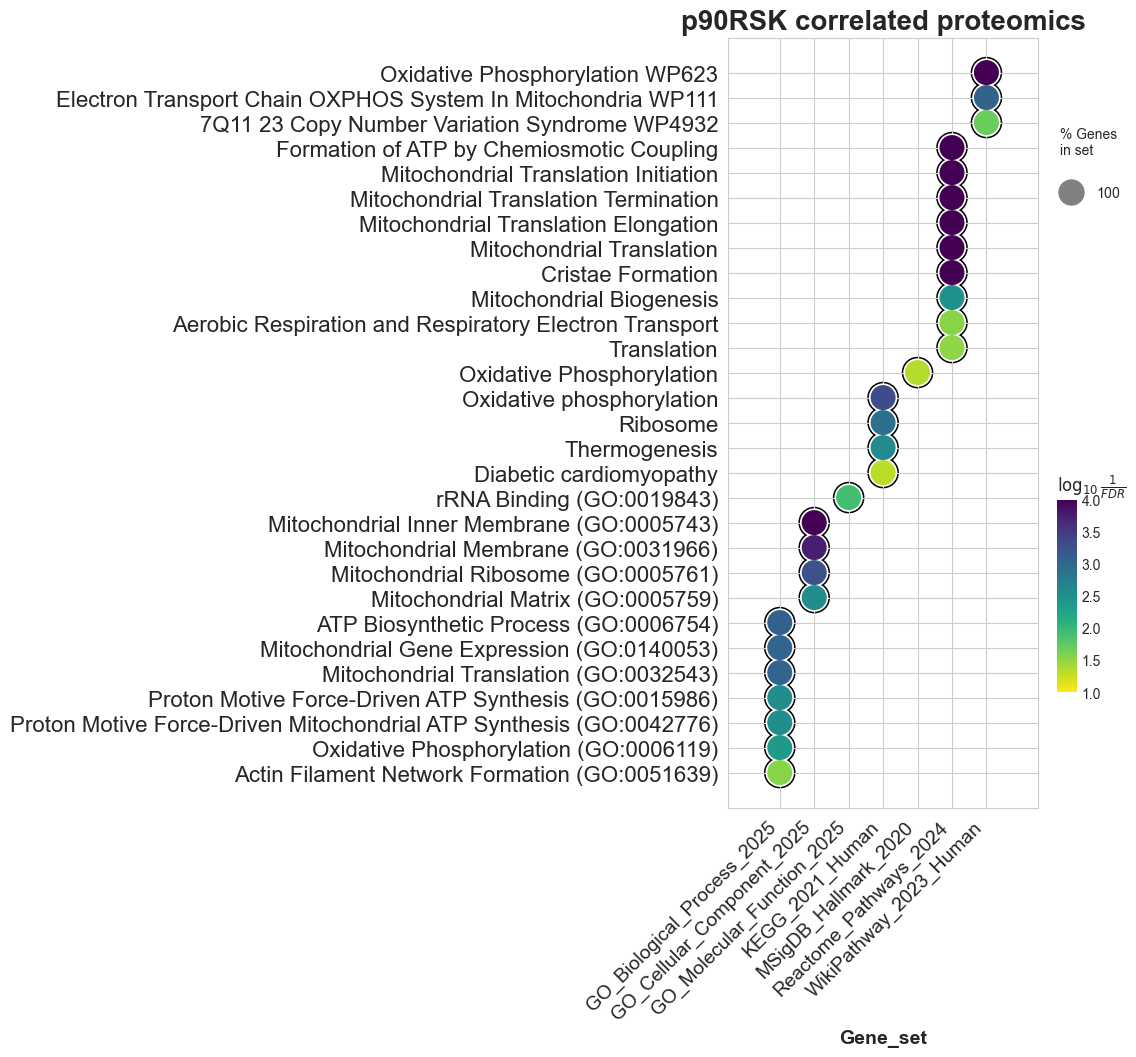

In [140]:
ax = gp.dotplot(
    enr_px.results,
    column="Adjusted P-value",
    x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
    size=3,
    figsize=(5,10),
    title = "p90RSK correlated proteomics",
    xticklabels_rot=45, # rotate xtick labels
    show_ring=True, # set to False to remove outer ring
    marker='o',
)